In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
image_dir = "/content/drive/MyDrive/images"
annot_path = "/content/drive/MyDrive/annotations.csv"

In [28]:
import os, cv2, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv(annot_path)
df.head()

,image,center_x,center_y,bbox_x,bbox_y,bbox_w,bbox_h,bbox_rotation,angle_deg
0,2659ffa5-color.png,343.5,89.6,326.0,68.6,38.5,37.9,0.0,41.9
1,2659ffa5-color.png,345.3,145.0,326.0,125.7,40.3,36.1,0.0,136.1
2,2659ffa5-color.png,346.5,200.9,332.0,179.8,29.5,43.9,0.0,263.3
3,2659ffa5-color.png,413.2,200.9,398.8,178.6,29.5,42.1,0.0,115.1
4,2659ffa5-color.png,412.0,143.2,393.4,125.7,40.9,33.7,0.0,334.1


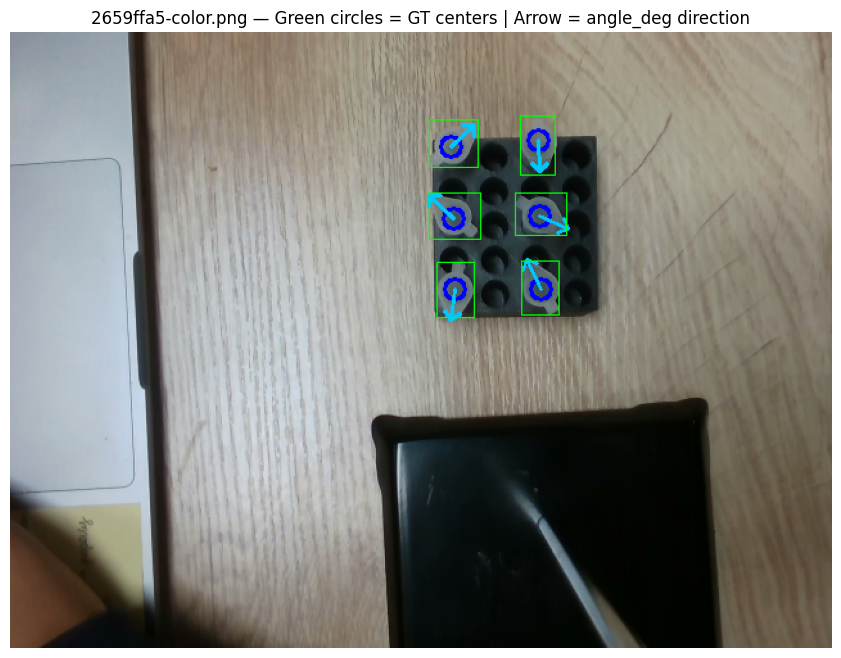

In [31]:
def get_gt(img, row):
  vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
  for _,r in row.iterrows():
    cx = int(r['center_x'])
    cy = int(r['center_y'])
    angle_rad = math.radians(r['angle_deg'])
    tx = int(cx + 25*math.cos(angle_rad))
    ty = int(cy - 25*math.sin(angle_rad))
    cv2.circle(vis, (cx,cy), 8, (0,0,255), 2)
    cv2.arrowedLine(vis, (cx,cy), (tx,ty), (0,200,255), 2, tipLength=0.35)
    bx = int(r['bbox_x'])
    by = int(r['bbox_y'])
    bw = int(r['bbox_w'])
    bh = int(r['bbox_h'])
    cv2.rectangle(vis, (bx,by), (bx+bw, by+bh), (0,255,0), 1)
  return vis
sample_img = df['image'].iloc[0]
sample_row = df[df['image'] == sample_img]
img = cv2.imread(os.path.join(image_dir, sample_img))

vis = get_gt(img, sample_row)
plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(f"{sample_img} — Green circles = GT centers | Arrow = angle_deg direction")
plt.axis('off')
plt.show()


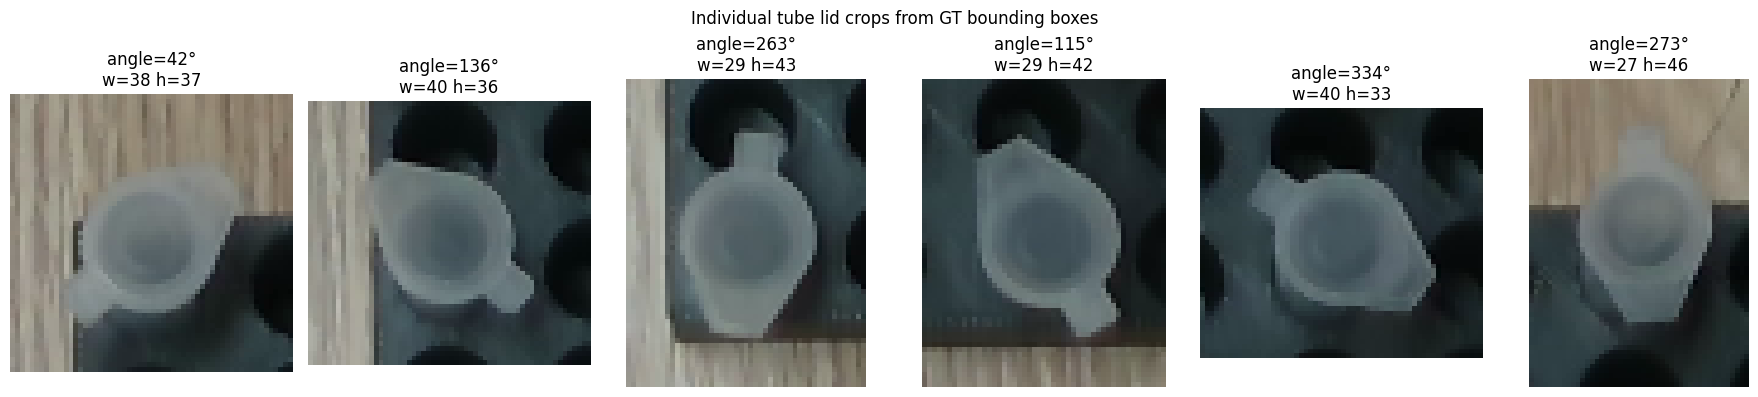

In [32]:
def show_tube_crops(img, row, padding=10):
  fig, axes = plt.subplots(1, len(row), figsize=(3*len(row), 4))
  if len(row) == 1:
    axes = [axes]
  for ax, (_,r) in zip(axes, row.iterrows()):
    bx = int(r['bbox_x'])
    by = int(r['bbox_y'])
    bw = int(r['bbox_w'])
    bh = int(r['bbox_h'])
    crop = img[max(0, by-padding):by+bh+padding, max(0, bx-padding):bx+bw+padding]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    ax.imshow(crop_rgb)
    ax.set_title(f"angle={r.angle_deg:.0f}°\nw={bw} h={bh}")
    ax.axis('off')
  plt.suptitle("Individual tube lid crops from GT bounding boxes")
  plt.tight_layout()
  plt.show()


show_tube_crops(img, sample_row)

In [33]:
def find_tray_variance(img_bgr, debug=False):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    k  = 50
    kn = np.ones((k, k), np.float32) / k**2
    lm  = cv2.filter2D(blurred.astype(np.float32), -1, kn)
    lm2 = cv2.filter2D(blurred.astype(np.float32)**2, -1, kn)
    lstd = np.sqrt(np.clip(lm2 - lm**2, 0, None)).astype(np.uint8)

    dark_mask = (lm  <  130).astype(np.uint8) * 255
    var_mask  = (lstd >   12).astype(np.uint8) * 255
    combined  = cv2.bitwise_and(dark_mask, var_mask)

    k2 = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k2)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  k2)

    contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        print("  Variance fallback also failed — using full image")
        return np.ones(img_bgr.shape[:2], dtype=np.uint8) * 255, None

    img_area = img_bgr.shape[0] * img_bgr.shape[1]
    best, best_score = None, 0
    for cnt in contours:
        a = cv2.contourArea(cnt)
        if a < 0.015 * img_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        aspect = min(w, h) / max(w, h)
        score  = a * aspect
        if score > best_score:
            best_score, best = score, cnt

    if best is None:
        return np.ones(img_bgr.shape[:2], dtype=np.uint8) * 255, None

    x, y, w, h = cv2.boundingRect(best)
    pad = 18
    x1 = max(0, x-pad);  y1 = max(0, y-pad)
    x2 = min(img_bgr.shape[1]-1, x+w+pad)
    y2 = min(img_bgr.shape[0]-1, y+h+pad)

    mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    mask[y1:y2, x1:x2] = 255

    if debug:
        vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        vis[mask == 0] = [25, 25, 25]
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Original")
        axes[1].imshow(lstd, cmap='hot')
        axes[1].set_title("Local texture variance\n(hot = high variance)")
        axes[2].imshow(vis)
        axes[2].set_title("Variance fallback search region")
        for ax in axes: ax.axis('off')
        plt.tight_layout()
        plt.show()

    return mask, None

Image 40: 8f501e6b-color.png
  Found 9 raw circles


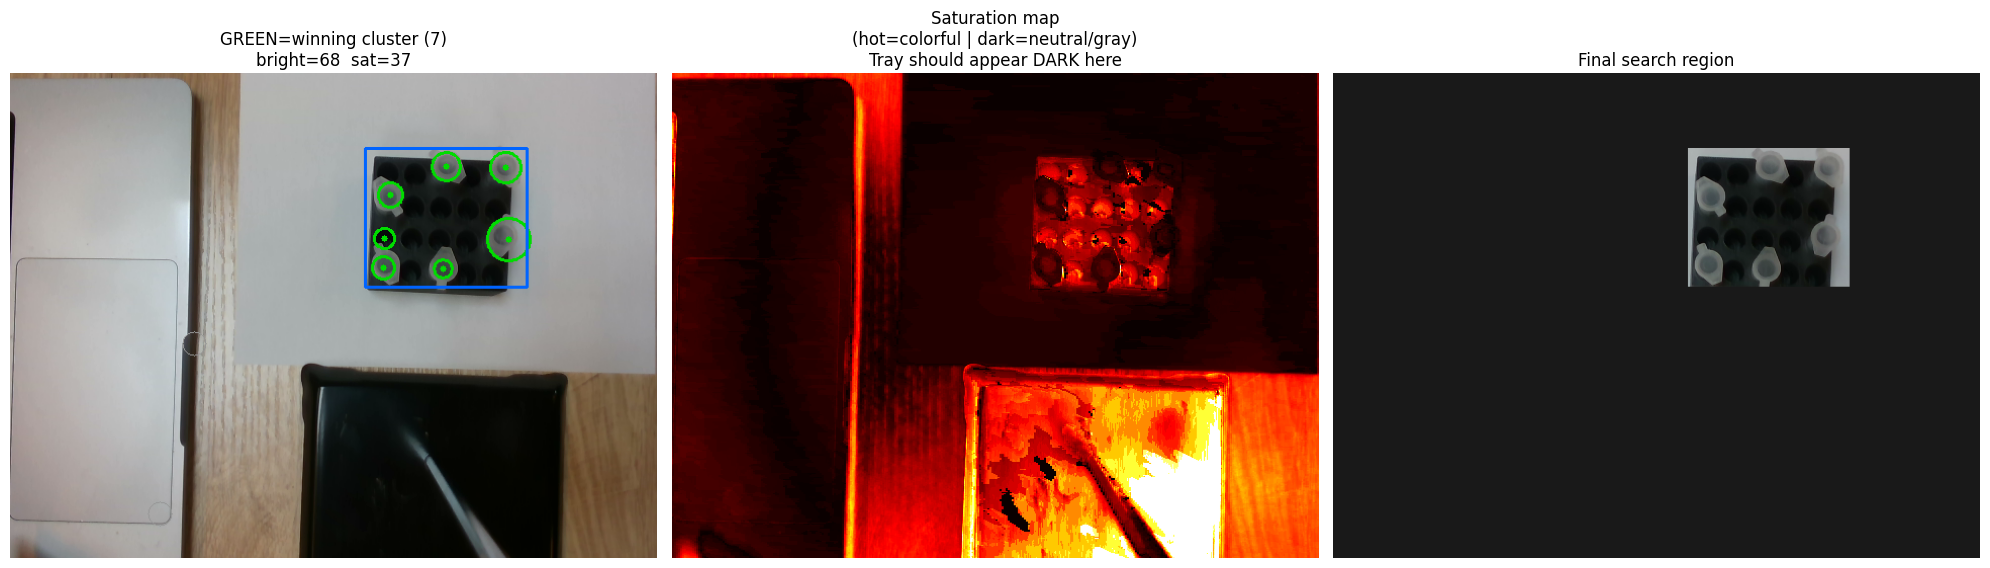

In [35]:
def find_tray_by_holes(img_bgr, debug=False):
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    sat     = hsv[:, :, 1]
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2, minDist=20,
        param1=50, param2=18,
        minRadius=8, maxRadius=22
    )

    if circles is None:
        print("  No circles — variance fallback")
        return find_tray_variance(img_bgr, debug=debug)

    circles = np.round(circles[0]).astype(int)
    if debug:
        print(f"  Found {len(circles)} raw circles")

    NEIGHBOR_RADIUS = 130

    best_score = -1
    best_idx   = 0

    for i, (cx, cy, r) in enumerate(circles):
        neighbors = [(cx2,cy2,r2) for (cx2,cy2,r2) in circles
                     if math.hypot(cx2-cx, cy2-cy) < NEIGHBOR_RADIUS]

        if len(neighbors) < 3:
            continue

        nxs = [c[0] for c in neighbors]
        nys = [c[1] for c in neighbors]
        rx1 = max(0, min(nxs)-20);  ry1 = max(0, min(nys)-20)
        rx2 = min(gray.shape[1]-1, max(nxs)+20)
        ry2 = min(gray.shape[0]-1, max(nys)+20)

        region_gray = gray[ry1:ry2, rx1:rx2]
        region_sat  = sat [ry1:ry2, rx1:rx2]

        if region_gray.size == 0:
            continue

        region_brightness  = region_gray.mean()
        region_saturation  = region_sat.mean()

        # Three factors that identify the tray
        # Factor 1: darkness
        darkness  = 1.0 - (region_brightness / 255.0)

        # Factor 2: neutrality
        neutrality = 1.0 - (region_saturation / 255.0)

        # Factor 3: density (more neighbors = denser grid)
        density = len(neighbors)

        # Combined score: density * darkness * neutrality²
        score = density * darkness * (neutrality ** 2)

        if score > best_score:
            best_score = score
            best_idx   = i

    if best_score < 0.5:
        print("  No confident cluster — variance fallback")
        return find_tray_variance(img_bgr, debug=debug)

    best_cx, best_cy, _ = circles[best_idx]
    cluster = [(cx,cy,r) for (cx,cy,r) in circles
               if math.hypot(cx-best_cx, cy-best_cy) < NEIGHBOR_RADIUS]

    xs  = [c[0] for c in cluster]
    ys  = [c[1] for c in cluster]

    rx1 = max(0, min(xs)-20);  ry1 = max(0, min(ys)-20)
    rx2 = min(gray.shape[1]-1, max(xs)+20)
    ry2 = min(gray.shape[0]-1, max(ys)+20)
    final_brightness  = gray[ry1:ry2, rx1:rx2].mean()
    final_saturation  = sat [ry1:ry2, rx1:rx2].mean()

    pad = 18
    x1 = max(0,                    min(xs)-pad)
    y1 = max(0,                    min(ys)-pad)
    x2 = min(img_bgr.shape[1]-1,   max(xs)+pad)
    y2 = min(img_bgr.shape[0]-1,   max(ys)+pad)

    region_mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    region_mask[y1:y2, x1:x2] = 255

    if debug:
        vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        for (cx,cy,r) in circles:
            cv2.circle(vis, (cx,cy), r, (150,150,150), 1)
        for (cx,cy,r) in cluster:
            cv2.circle(vis, (cx,cy), r, (0,220,0), 2)
            cv2.circle(vis, (cx,cy), 3, (0,220,0), -1)
        cv2.rectangle(vis, (x1,y1), (x2,y2), (0,100,255), 2)

        masked = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        masked[region_mask == 0] = [25,25,25]

        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        axes[0].imshow(vis)
        axes[0].set_title(f"GREEN=winning cluster ({len(cluster)})\n"
                          f"bright={final_brightness:.0f}  sat={final_saturation:.0f}")
        axes[0].axis('off')

        axes[1].imshow(sat, cmap='hot')
        axes[1].set_title("Saturation map\n(hot=colorful | dark=neutral/gray)\n"
                          "Tray should appear DARK here")
        axes[1].axis('off')

        axes[2].imshow(masked)
        axes[2].set_title("Final search region")
        axes[2].axis('off')
        plt.tight_layout()
        plt.show()

    return region_mask, cluster


def find_tray(img_bgr, debug=False):
    result = find_tray_by_holes(img_bgr, debug=debug)
    region_mask = result[0] if isinstance(result, tuple) else result
    return region_mask


image_list = df['image'].unique()
idx = 40
name = image_list[idx]
img_final = cv2.imread(os.path.join(image_dir, name))
print(f"Image {idx}: {name}")
mask = find_tray(img_final, debug=True)

Image 0: 2659ffa5-color.png  |  GT tubes: 6
  DoG stats (inner): mean=2.22  std=24.72  threshold=22.00


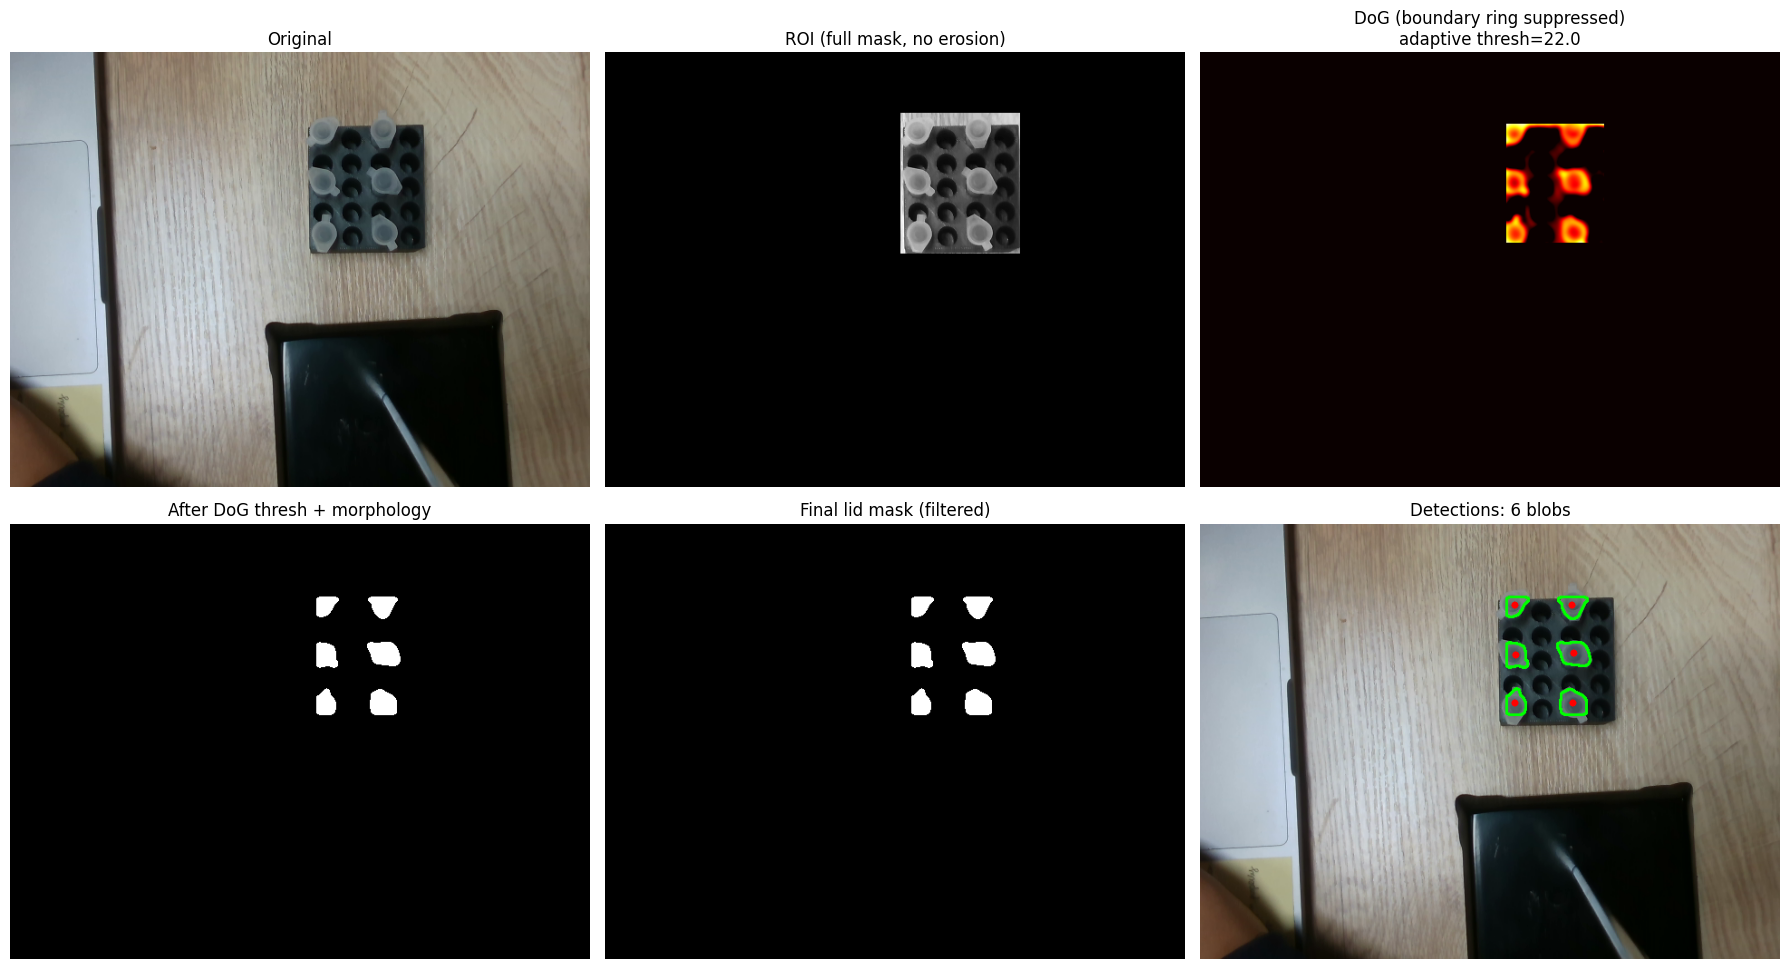


  Blobs found: 6
    (412,142)  area=  745  circ=0.78
    (411,197)  area=  686  circ=0.85
    (348,144)  area=  532  circ=0.74
    (410, 89)  area=  515  circ=0.73
    (347,197)  area=  475  circ=0.81
    (347, 89)  area=  390  circ=0.76
Image 10: e8063e46-color.png  |  GT tubes: 6
  DoG stats (inner): mean=1.65  std=25.65  threshold=22.17


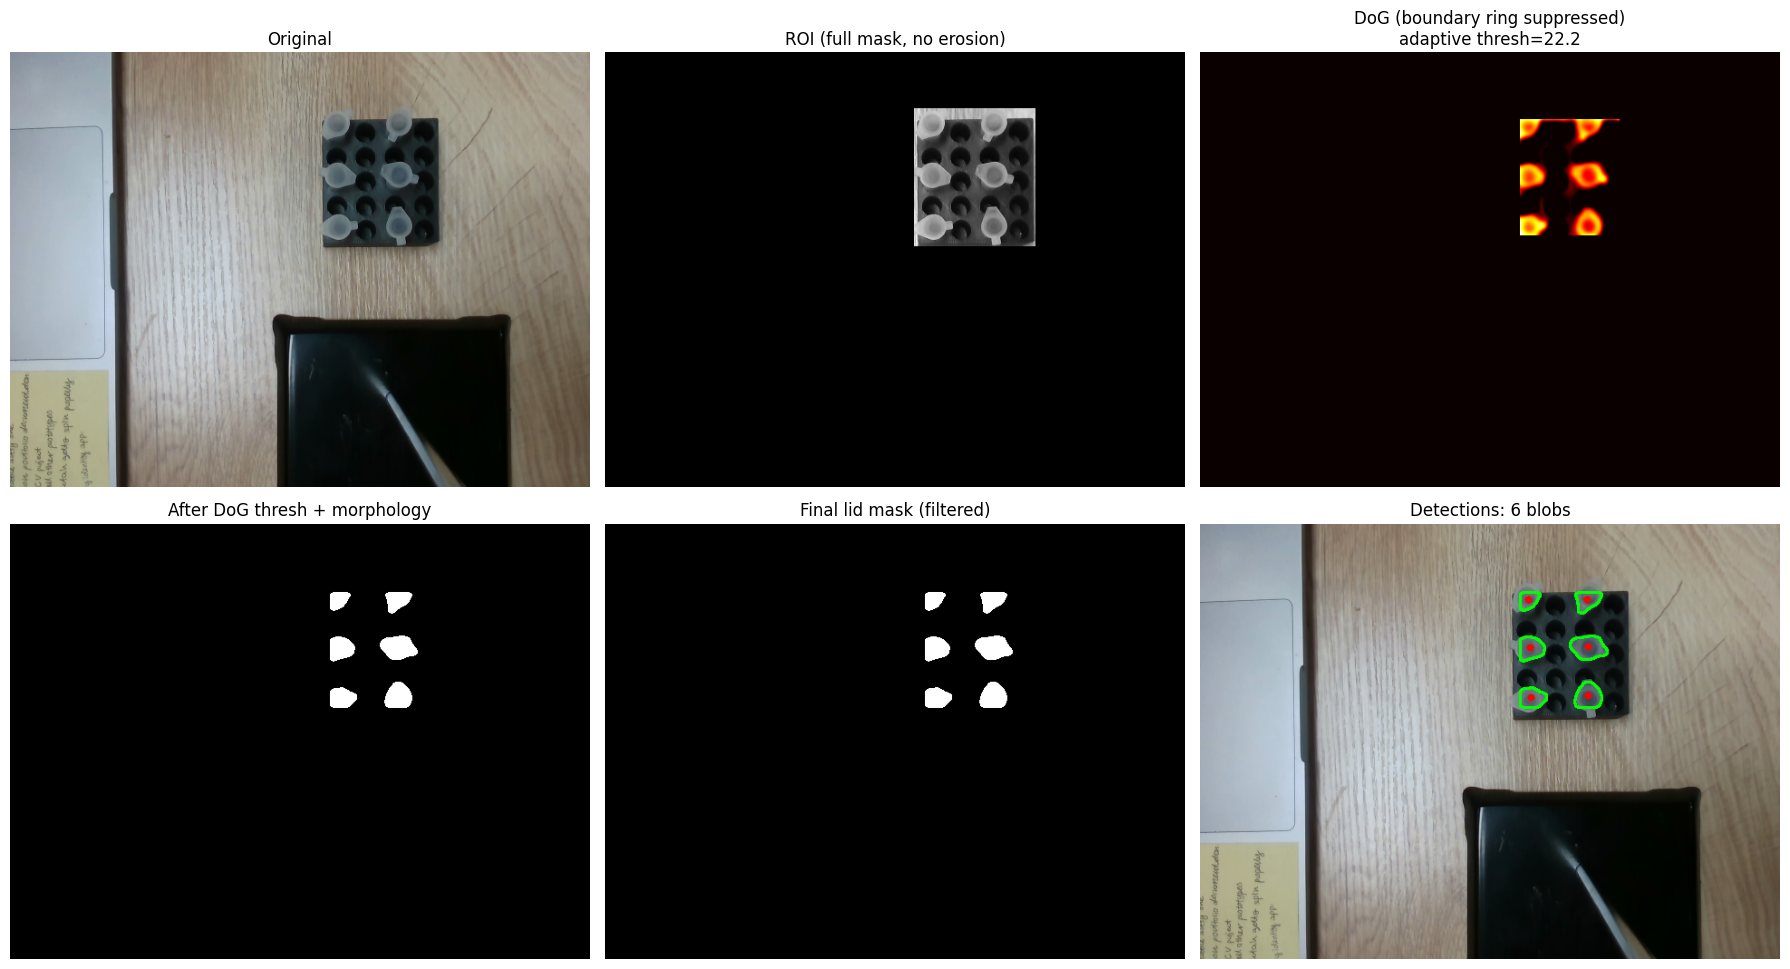


  Blobs found: 6
    (428,135)  area=  784  circ=0.78
    (428,189)  area=  657  circ=0.85
    (364,136)  area=  562  circ=0.81
    (365,191)  area=  516  circ=0.83
    (427, 83)  area=  450  circ=0.71
    (362, 83)  area=  332  circ=0.77
Image 20: 5cacee7d-color.png  |  GT tubes: 6
  DoG stats (inner): mean=2.34  std=24.81  threshold=22.19


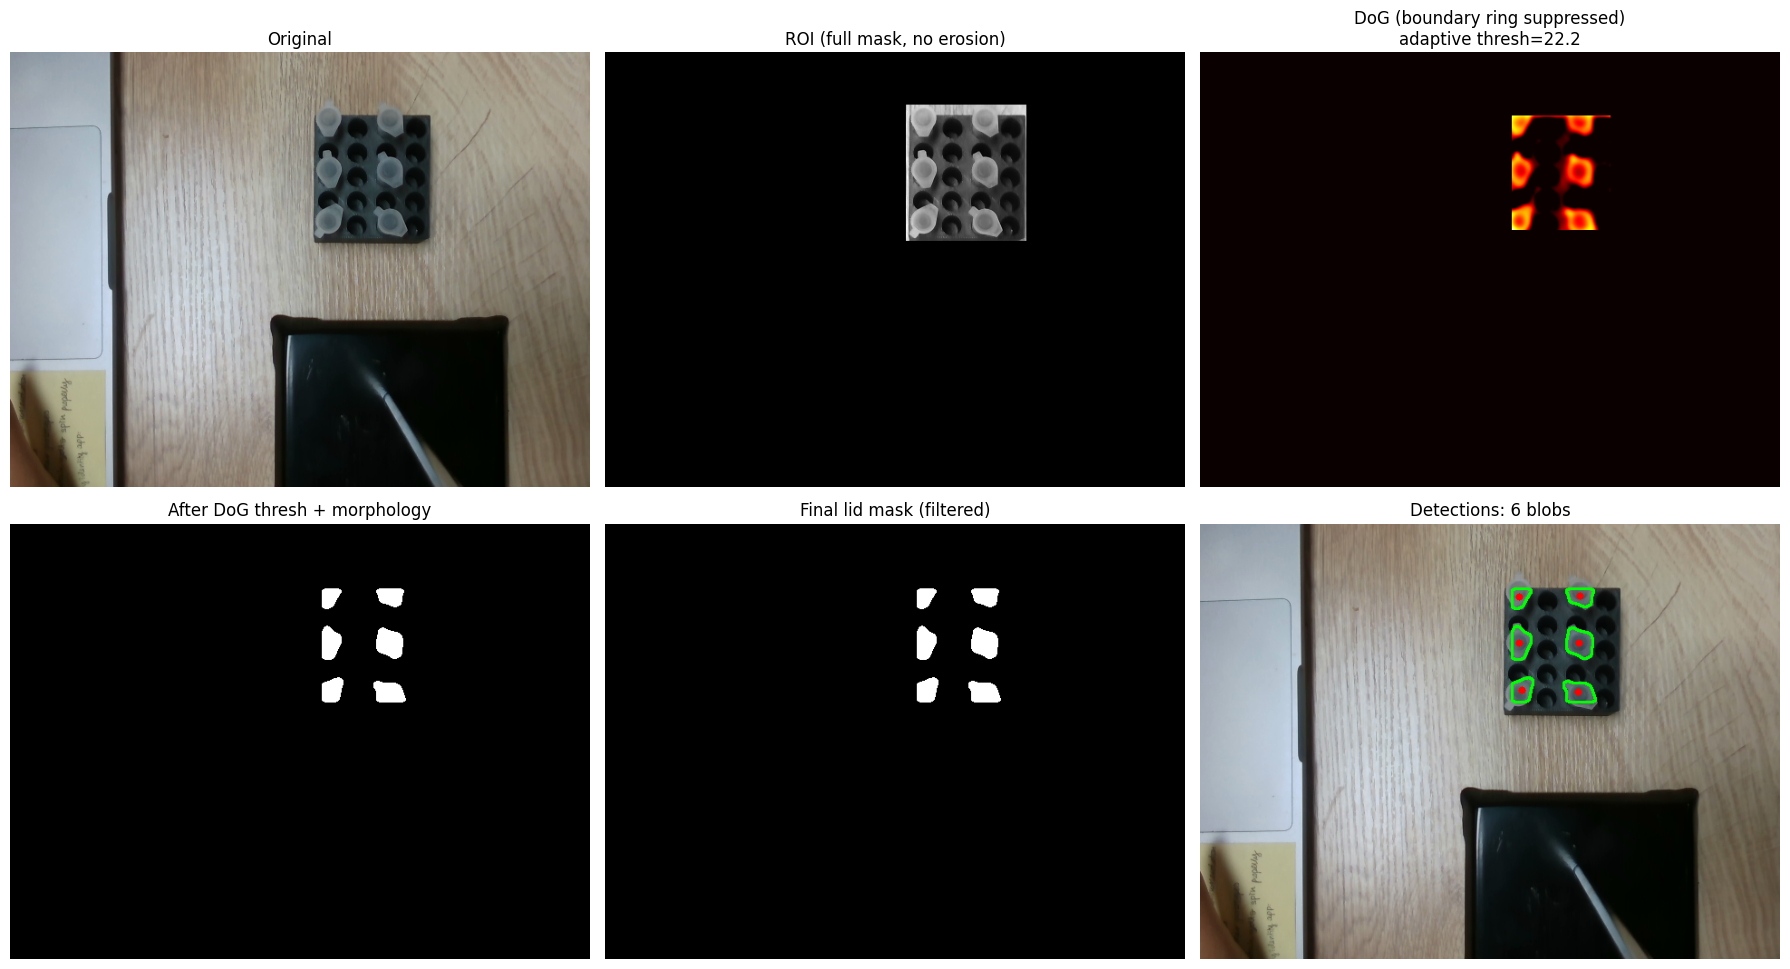


  Blobs found: 6
    (418,131)  area=  754  circ=0.81
    (417,185)  area=  635  circ=0.73
    (352,131)  area=  592  circ=0.74
    (355,183)  area=  500  circ=0.80
    (419, 79)  area=  463  circ=0.75
    (352, 80)  area=  347  circ=0.77


In [36]:
def segment_lids(img_bgr, region_mask, debug=False):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    roi_gray = cv2.bitwise_and(gray, gray, mask=region_mask)

    # Difference of Gaussians
    float_img  = roi_gray.astype(np.float32)
    blur_small = cv2.GaussianBlur(float_img, (0,0), sigmaX=3)
    blur_large = cv2.GaussianBlur(float_img, (0,0), sigmaX=18)
    dog        = blur_small - blur_large

    # Zero outside mask
    dog[region_mask == 0] = 0

    erode_k    = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))
    inner_mask = cv2.erode(region_mask, erode_k)
    border_ring = cv2.bitwise_xor(region_mask, inner_mask)
    dog[border_ring > 0] = 0

    dog_vals = dog[inner_mask > 0]

    if len(dog_vals) == 0:
        if debug:
            print("  Empty inner mask — returning empty")
        return np.zeros_like(region_mask)

    dog_mean = dog_vals.mean()
    dog_std  = dog_vals.std()

    dog_thresh = dog_mean + 0.8 * dog_std
    dog_thresh = max(dog_thresh, 5.0)   # never go below 5

    if debug:
        print(f"  DoG stats (inner): mean={dog_mean:.2f}  "
              f"std={dog_std:.2f}  threshold={dog_thresh:.2f}")

    lid_blob = (dog > dog_thresh).astype(np.uint8) * 255

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13,13))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    lid_blob = cv2.morphologyEx(lid_blob, cv2.MORPH_CLOSE, k_close)
    lid_blob = cv2.morphologyEx(lid_blob, cv2.MORPH_OPEN,  k_open)

    filled    = lid_blob.copy()
    h, w      = filled.shape
    fill_mask = np.zeros((h+2, w+2), dtype=np.uint8)
    cv2.floodFill(filled, fill_mask, (0,0), 255)
    lid_blob  = cv2.bitwise_or(lid_blob, cv2.bitwise_not(filled))

    cnts, _    = cv2.findContours(lid_blob, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    clean_mask = np.zeros_like(lid_blob)
    img_h, img_w = gray.shape
    EDGE_MARGIN  = 1

    for cnt in cnts:
        area = cv2.contourArea(cnt)
        if not (300 < area < 6000):
            continue

        perim = cv2.arcLength(cnt, True)
        if perim == 0:
            continue
        circ = 4 * math.pi * area / perim**2
        if circ < 0.28:
            continue

        x,y,bw,bh = cv2.boundingRect(cnt)
        if (x <= EDGE_MARGIN or y <= EDGE_MARGIN or
            x+bw >= img_w-EDGE_MARGIN or
            y+bh >= img_h-EDGE_MARGIN):
            continue

        cv2.drawContours(clean_mask, [cnt], -1, 255, cv2.FILLED)

    if debug:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        axes[0,0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        axes[0,0].set_title("Original")
        axes[0,0].axis('off')

        axes[0,1].imshow(roi_gray, cmap='gray')
        axes[0,1].set_title("ROI (full mask, no erosion)")
        axes[0,1].axis('off')

        dog_vis = np.clip(dog, 0, dog.max())
        axes[0,2].imshow(dog_vis, cmap='hot')
        axes[0,2].set_title(f"DoG (boundary ring suppressed)\n"
                             f"adaptive thresh={dog_thresh:.1f}")
        axes[0,2].axis('off')

        axes[1,0].imshow(lid_blob, cmap='gray')
        axes[1,0].set_title("After DoG thresh + morphology")
        axes[1,0].axis('off')

        axes[1,1].imshow(clean_mask, cmap='gray')
        axes[1,1].set_title("Final lid mask (filtered)")
        axes[1,1].axis('off')

        overlay = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        cnts2,_ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL,
                                    cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, cnts2, -1, (0,255,0), 2)
        for cnt in cnts2:
            M = cv2.moments(cnt)
            if M['m00'] > 0:
                cx = int(M['m10']/M['m00'])
                cy = int(M['m01']/M['m00'])
                cv2.circle(overlay, (cx,cy), 4, (255,0,0), -1)
        axes[1,2].imshow(overlay)
        axes[1,2].set_title(f"Detections: {len(cnts2)} blobs")
        axes[1,2].axis('off')

        plt.tight_layout()
        plt.show()

        gt_row = df[df['image'] ==
                       image_list[0]]
        print(f"\n  Blobs found: {len(cnts2)}")
        for cnt in sorted(cnts2, key=cv2.contourArea, reverse=True):
            area  = cv2.contourArea(cnt)
            perim = cv2.arcLength(cnt, True)
            circ  = 4*math.pi*area/perim**2 if perim > 0 else 0
            M     = cv2.moments(cnt)
            if M['m00'] > 0:
                cx = int(M['m10']/M['m00'])
                cy = int(M['m01']/M['m00'])
                print(f"    ({cx:3d},{cy:3d})  "
                      f"area={area:5.0f}  circ={circ:.2f}")

    return clean_mask


for idx in [0,10,20]:
    if idx >= len(image_list): continue
    name = image_list[idx]
    img  = cv2.imread(os.path.join(image_dir, name))
    gt_n = len(df[df['image'] == name])
    print(f"Image {idx}: {name}  |  GT tubes: {gt_n}")
    mask = find_tray(img, debug=False)
    lid_mask = segment_lids(img, mask, debug=True)

In [37]:
def find_tube_angle(img_bgr, cnt, cx, cy, debug=False):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    x, y, bw, bh = cv2.boundingRect(cnt)
    pad  = 5
    x1   = max(0, x - pad);   y1 = max(0, y - pad)
    x2   = min(w, x+bw+pad);  y2 = min(h, y+bh+pad)

    crop_gray = gray[y1:y2, x1:x2]
    crop_bgr  = img_bgr[y1:y2, x1:x2]

    if crop_gray.size == 0:
        return None

    _, thresh = cv2.threshold(crop_gray, 0, 255,
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, k)

    ys_px, xs_px = np.where(thresh > 0)
    if len(xs_px) < 10:
        return None

    pts = np.column_stack([xs_px, ys_px]).astype(np.float32)

    local_cx = cx - x1
    local_cy = cy - y1

    mean, eigvecs = cv2.PCACompute(pts, mean=None)
    main_axis = eigvecs[0]

    centered = pts - np.array([local_cx, local_cy])
    proj     = centered @ main_axis

    pos_mask = proj > 0
    neg_mask = proj < 0

    pos_pixels = pts[pos_mask]
    neg_pixels = pts[neg_mask]

    if len(pos_pixels) == 0 or len(neg_pixels) == 0:
        return None

    perp_axis = eigvecs[1]

    pos_perp = np.abs(centered[pos_mask] @ perp_axis)
    neg_perp = np.abs(centered[neg_mask] @ perp_axis)

    mean_pos_perp = pos_perp.mean()
    mean_neg_perp = neg_perp.mean()

    max_pos_proj = proj[pos_mask].max() if pos_mask.any() else 0
    max_neg_proj = abs(proj[neg_mask].min()) if neg_mask.any() else 0

    pos_tab_score = (1.0/max(mean_pos_perp, 0.1)) * (1.0/max(max_pos_proj, 0.1))
    neg_tab_score = (1.0/max(mean_neg_perp, 0.1)) * (1.0/max(max_neg_proj, 0.1))

    if pos_tab_score > neg_tab_score:
        tab_direction = main_axis
    else:
        tab_direction = -main_axis

    angle = math.degrees(math.atan2(-tab_direction[1],
                                     tab_direction[0])) % 360

    if debug:
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))

        axes[0].imshow(cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB))
        axes[0].set_title("Crop")
        axes[0].axis('off')

        axes[1].imshow(thresh, cmap='gray')
        center_pt = np.array([local_cx, local_cy])
        axes[1].annotate('', xy=center_pt + main_axis*30,
                          xytext=center_pt - main_axis*30,
                          arrowprops=dict(arrowstyle='->', color='red'))
        axes[1].set_title("Threshold + PCA axis")
        axes[1].axis('off')

        result = crop_bgr.copy()
        result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        tab_end = (int(local_cx + tab_direction[0]*35),
                   int(local_cy - tab_direction[1]*35))
        cv2.arrowedLine(result,
                        (int(local_cx), int(local_cy)),
                        tab_end, (255,100,0), 2, tipLength=0.3)
        axes[2].imshow(result)
        axes[2].set_title(f"Tab direction\nangle={angle:.1f}°")
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    return angle


In [38]:
def detect_tubes(img_bgr, lid_mask, debug=False):
    contours, _ = cv2.findContours(lid_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    detections = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (300 < area < 6000):
            continue

        perim = cv2.arcLength(cnt, True)
        if perim == 0:
            continue
        if 4*math.pi*area/perim**2 < 0.28:
            continue

        M = cv2.moments(cnt)
        if M['m00'] == 0:
            continue
        cx = M['m10'] / M['m00']
        cy = M['m01'] / M['m00']

        angle = find_tube_angle(img_bgr, cnt, cx, cy, debug=False)

        if angle is None:
            pts   = cnt.reshape(-1,2).astype(float)
            diffs = pts - np.array([cx, cy])
            dists = np.linalg.norm(diffs, axis=1)
            tab_x, tab_y = pts[np.argmax(dists)]
            angle = math.degrees(math.atan2(-(tab_y-cy), tab_x-cx)) % 360

        detections.append({
            'cx'     : cx,
            'cy'     : cy,
            'angle'  : angle,
            'area'   : area,
            'contour': cnt
        })

    if debug:
        vis = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
        for d in detections:
            cx, cy  = int(d['cx']), int(d['cy'])
            ar      = math.radians(d['angle'])
            tx = int(cx + 30*math.cos(ar))
            ty = int(cy - 30*math.sin(ar))
            cv2.drawContours(vis, [d['contour']], -1, (100,255,100), 1)
            cv2.circle(vis, (cx,cy), 5, (255,60,60), -1)
            cv2.arrowedLine(vis, (cx,cy), (tx,ty), (255,200,0), 2,
                            tipLength=0.35)
            cv2.putText(vis, f"{d['angle']:.0f}",
                        (cx+6,cy-6), cv2.FONT_HERSHEY_SIMPLEX,
                        0.4, (255,255,100), 1)
        plt.figure(figsize=(12,8))
        plt.imshow(vis)
        plt.title(f"{len(detections)} tubes detected (v2 angles)")
        plt.axis('off')
        plt.show()

    return detections



In [39]:
def run_pipeline(img_bgr, debug=False):
    region_mask = find_tray(img_bgr)
    lid_mask = segment_lids(img_bgr, region_mask, debug=debug)
    detections = detect_tubes(img_bgr, lid_mask, debug=debug)
    return detections

all_predictions = {}

for img_name in image_list:
    img = cv2.imread(os.path.join(image_dir, img_name))
    if img is None:
        print(f"Cannot read: {img_name}")
        continue
    dets = run_pipeline(img, debug=False)
    all_predictions[img_name] = [
        {'cx': d['cx'], 'cy': d['cy'], 'angle': d['angle']}
        for d in dets
    ]
    gt_n = len(df[df['image'] == img_name])
    pred_n = len(all_predictions[img_name])
    status = 'All lids predicted' if gt_n == pred_n else f'Not matching with ground truth.. GT={gt_n} Pred={pred_n}'
    print(f"{img_name}: {status}")

2659ffa5-color.png: All lids predicted
dd60aa44-color.png: All lids predicted
26ec68e2-color.png: All lids predicted
6f323235-color.png: All lids predicted
07865578-color.png: All lids predicted
f05074cb-color.png: All lids predicted
47649de1-color.png: All lids predicted
04f3656c-color.png: All lids predicted
f789f7cb-color.png: All lids predicted
5a8da514-color.png: All lids predicted
e8063e46-color.png: All lids predicted
7eb1d29b-color.png: All lids predicted
a6f2e215-color.png: All lids predicted
e2ad11c8-color.png: All lids predicted
49e44369-color.png: All lids predicted
bbd88e30-color.png: All lids predicted
d38ea15e-color.png: All lids predicted
a12a596c-color.png: All lids predicted
291c88b4-color.png: All lids predicted
2c073c5b-color.png: All lids predicted
5cacee7d-color.png: All lids predicted
42f1d5fe-color.png: All lids predicted
71f023c4-color.png: Not matching with ground truth.. GT=6 Pred=5
ed54ad54-color.png: All lids predicted
087dcfd7-color.png: All lids predicted

In [40]:
def angular_error_360(pred, gt):
    diff = abs(pred - gt) % 360
    return min(diff, 360 - diff)


def evaluate(all_predictions, gt_df, dist_thresh=30):
    total_tp = total_fp = total_fn = 0
    all_center_errs = []
    all_angle_errs  = []
    per_image       = {}

    for img_name in gt_df['image'].unique():
        preds = all_predictions.get(img_name, [])
        gts   = gt_df[gt_df['image'] == img_name].to_dict('records')

        used_preds    = set()
        matched_pairs = []

        for gt in gts:
            best_dist, best_i = float('inf'), -1
            for i, pred in enumerate(preds):
                if i in used_preds:
                    continue
                d = math.hypot(pred['cx'] - gt['center_x'],
                               pred['cy'] - gt['center_y'])
                if d < best_dist:
                    best_dist, best_i = d, i

            if best_i >= 0 and best_dist <= dist_thresh:
                pred = preds[best_i]
                used_preds.add(best_i)
                a_err = angular_error_360(pred['angle'], gt['angle_deg'])
                matched_pairs.append({
                    'dist'     : best_dist,
                    'angle_err': a_err,
                    'pred_cx'  : pred['cx'],
                    'pred_cy'  : pred['cy'],
                    'gt_cx'    : gt['center_x'],
                    'gt_cy'    : gt['center_y'],
                })
                all_center_errs.append(best_dist)
                all_angle_errs.append(a_err)

        tp = len(matched_pairs)
        fp = len(preds) - len(used_preds)
        fn = len(gts)   - tp

        total_tp += tp
        total_fp += fp
        total_fn += fn

        per_image[img_name] = {
            'n_gt'           : len(gts),
            'n_pred'         : len(preds),
            'tp'             : tp,
            'fp'             : fp,
            'fn'             : fn,
            'mean_center_err': np.mean([m['dist']      for m in matched_pairs]) if matched_pairs else None,
            'mean_angle_err' : np.mean([m['angle_err'] for m in matched_pairs]) if matched_pairs else None,
        }

    precision = total_tp/(total_tp+total_fp) if (total_tp+total_fp) > 0 else 0
    recall    = total_tp/(total_tp+total_fn) if (total_tp+total_fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0


    print("            EVALUATION RESULTS")
    print(f"  Total GT tubes        : {total_tp+total_fn}")
    print(f"  True Positives  (TP)  : {total_tp}")
    print(f"  False Positives (FP)  : {total_fp}   (extra detections)")
    print(f"  False Negatives (FN)  : {total_fn}   (missed tubes)")
    print(f"  Precision             : {precision:.3f}")
    print(f"  Recall                : {recall:.3f}")
    print(f"  F1 Score              : {f1:.3f}")
    print(f"\n  Mean  Center Error    : {np.mean(all_center_errs):.2f} px")
    print(f"  Median Center Error   : {np.median(all_center_errs):.2f} px")
    print(f"  Std   Center Error    : {np.std(all_center_errs):.2f} px")
    print(f"\n  Mean  Angle Error     : {np.mean(all_angle_errs):.2f}°")
    print(f"  Median Angle Error    : {np.median(all_angle_errs):.2f}°")
    print(f"  Std   Angle Error     : {np.std(all_angle_errs):.2f}°")

    return per_image, all_center_errs, all_angle_errs


per_image_results, center_errs, angle_errs = evaluate(all_predictions, df)

            EVALUATION RESULTS
  Total GT tubes        : 371
  True Positives  (TP)  : 367
  False Positives (FP)  : 6   (extra detections)
  False Negatives (FN)  : 4   (missed tubes)
  Precision             : 0.984
  Recall                : 0.989
  F1 Score              : 0.987

  Mean  Center Error    : 3.86 px
  Median Center Error   : 3.58 px
  Std   Center Error    : 2.42 px

  Mean  Angle Error     : 71.04°
  Median Angle Error    : 22.94°
  Std   Angle Error     : 74.82°


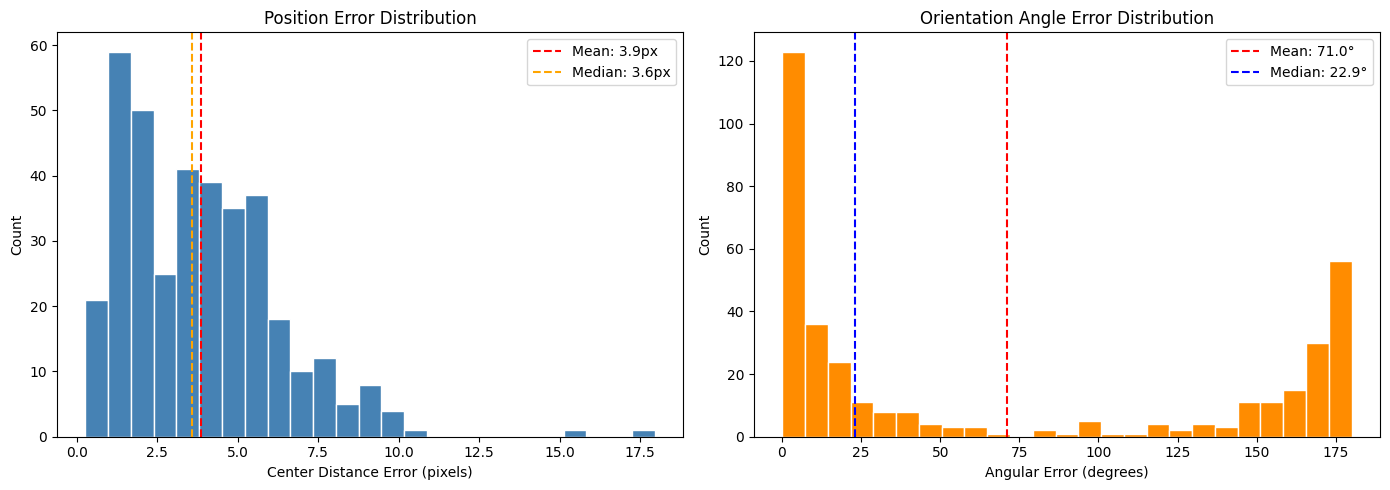

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(center_errs, bins=25, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(center_errs), color='red', linestyle='--',
                label=f'Mean: {np.mean(center_errs):.1f}px')
axes[0].axvline(np.median(center_errs), color='orange', linestyle='--',
                label=f'Median: {np.median(center_errs):.1f}px')
axes[0].set_xlabel("Center Distance Error (pixels)")
axes[0].set_ylabel("Count")
axes[0].set_title("Position Error Distribution")
axes[0].legend()

axes[1].hist(angle_errs, bins=25, color='darkorange', edgecolor='white')
axes[1].axvline(np.mean(angle_errs), color='red', linestyle='--',
                label=f'Mean: {np.mean(angle_errs):.1f}°')
axes[1].axvline(np.median(angle_errs), color='blue', linestyle='--',
                label=f'Median: {np.median(angle_errs):.1f}°')
axes[1].set_xlabel("Angular Error (degrees)")
axes[1].set_ylabel("Count")
axes[1].set_title("Orientation Angle Error Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

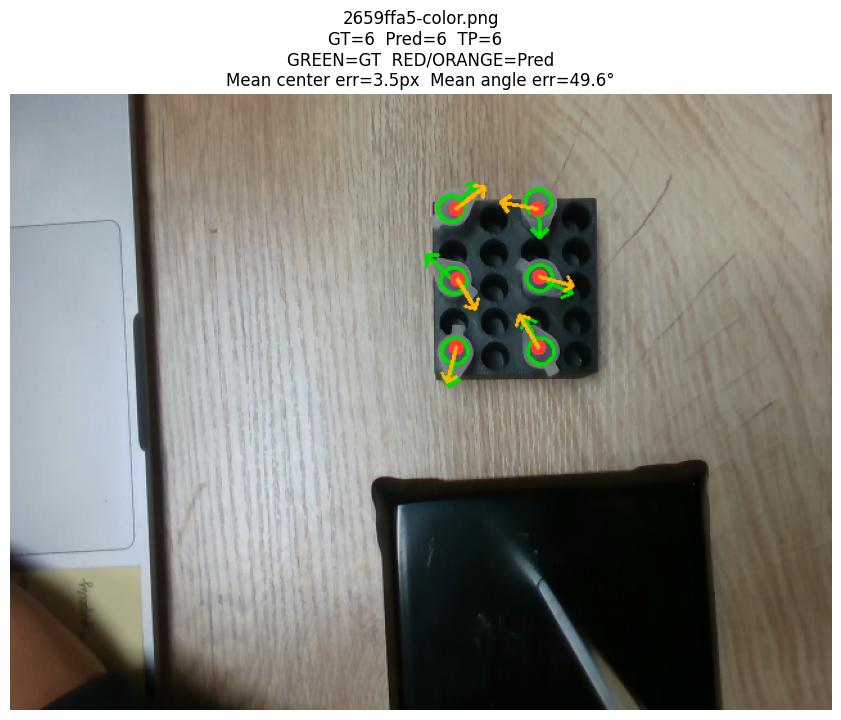

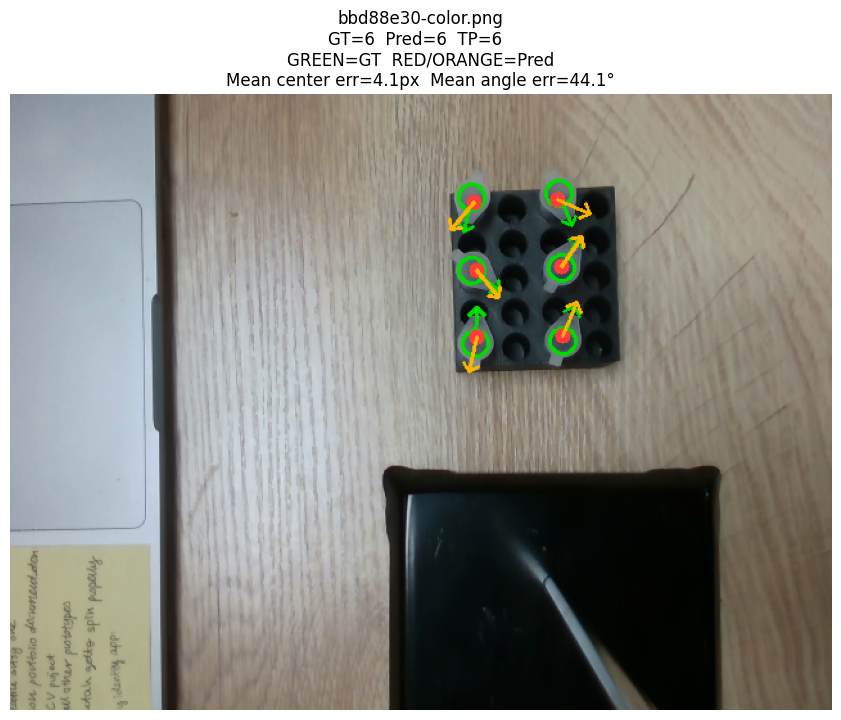

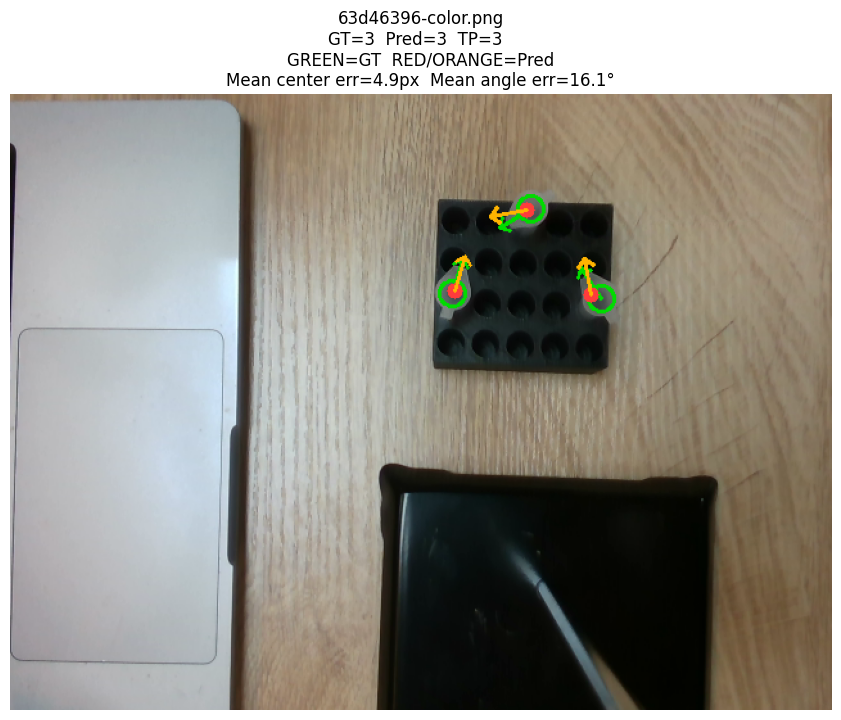

In [44]:
def compare_gt_vs_pred(img_name):
    img   = cv2.imread(os.path.join(image_dir, img_name))
    vis   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
    gts   = df[df['image'] == img_name]
    preds = all_predictions.get(img_name, [])

    # Ground truth → GREEN
    for _, r in gts.iterrows():
        cx, cy = int(r.center_x), int(r.center_y)
        ar = math.radians(r.angle_deg)
        cv2.circle(vis, (cx,cy), 10, (0,220,0), 2)
        cv2.arrowedLine(vis, (cx,cy),
            (int(cx+28*math.cos(ar)), int(cy-28*math.sin(ar))),
            (0,220,0), 2, tipLength=0.3)

    # Predictions → RED center + ORANGE arrow
    for p in preds:
        cx, cy = int(p['cx']), int(p['cy'])
        ar = math.radians(p['angle'])
        cv2.circle(vis, (cx,cy), 6, (255,60,60), -1)
        cv2.arrowedLine(vis, (cx,cy),
            (int(cx+28*math.cos(ar)), int(cy-28*math.sin(ar))),
            (255,180,0), 2, tipLength=0.3)

    gt_n   = len(gts)
    pred_n = len(preds)
    r_img  = per_image_results.get(img_name, {})
    tp     = r_img.get('tp', 0)
    ce     = r_img.get('mean_center_err')
    ae     = r_img.get('mean_angle_err')

    plt.figure(figsize=(12,8))
    plt.imshow(vis)
    plt.title(f"{img_name}\n"
              f"GT={gt_n}  Pred={pred_n}  TP={tp}  "
              f"\n"
              f"GREEN=GT  RED/ORANGE=Pred\n"
              f"Mean center err={ce:.1f}px  "
              f"Mean angle err={ae:.1f}°" if ce else "No matches")
    plt.axis('off')
    plt.show()

# Show all images
for idx in [0,15,25]:
    if idx >= len(image_list): continue
    name = image_list[idx]
    img  = cv2.imread(os.path.join(image_dir, name))
    gt_n = len(df[df['image'] == name])
    compare_gt_vs_pred(name)